# Distributional Robustness in Games via Coherent Risk Measures

This notebook explores mixed complementarity problem (MCP) solvers and related game-theoretic models, with visualizations and numerical experiments. It includes plotting utilities, linear and complementarity formulations, and example games to compare solver behavior.


## Requirements

In [12]:
# Python requirements
!pip -q install numpy matplotlib pandas pyomo scipy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Solver
This notebook requires the `PATH` or `ipopt` solver to run the complementarity programmes. 

`PATH`: https://pages.cs.wisc.edu/~ferris/path.html
`ipopt`: https://coin-or.github.io/Ipopt/

If neither are available, the Fischer-Burmeister optimisation implementation can also be used 

## Instructions

1. Run the requirements cell if your environment is fresh.
2. Execute the notebook top-to-bottom to reproduce figures and experiments.
3. Re-run individual sections as needed when adjusting parameters.
4. If a solver backend is missing, install it and re-run the affected section.


## Table of Contents

1. Graphs (Fig 1, Fig 2)
1. Zero-Sum Linear Program
1. Pyomo Complementarity (MSD, CVaR)
1. Fischer-Burmeister (FB) NCP Solver
1. Experiments (Coordination game; Prisoner's Dilemma; Fig 3; Non zero-sum game; Fig 4)


# Graphs

## Fig 1

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_394/3202981807.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel(r'$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$', labelpad=10)


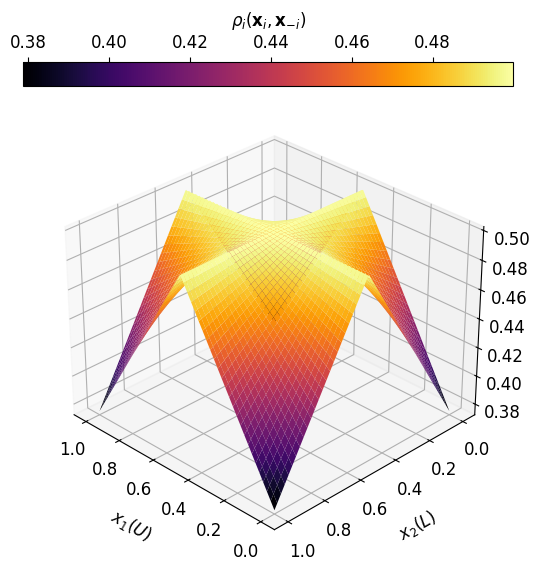

In [1]:
"""import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # noqa: F401

# Global font size
plt.rcParams.update({
"font.size": 12,
"axes.labelsize": 12,
"xtick.labelsize": 12,
"ytick.labelsize": 12,
})

# Strategy grids
x1 = np.linspace(0, 1, 200)
x2 = np.linspace(0, 1, 200)
X1, X2 = np.meshgrid(x1, x2)

# Ambiguity set
p_min, p_max = 0.3, 0.7
term = (1 - 2*X1) * (1 - 2*X2)

rho_pmin = 0.5 + 0.5 * (2*p_min - 1) * term
rho_pmax = 0.5 + 0.5 * (2*p_max - 1) * term
rho = np.minimum(rho_pmin, rho_pmax)

# Figure
fig = plt.figure(figsize=(7, 6))

# Main 3D plot
ax = fig.add_axes([0.05, 0.05, 0.9, 0.75], projection='3d')
surf = ax.plot_surface(X1, X2, rho, cmap='inferno', linewidth=0)

ax.set_xlabel(r'$x_1(U)$', labelpad=10)
ax.set_ylabel(r'$x_2(L)$', labelpad=10)
ax.set_zlabel(r'$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$', labelpad=10)
ax.view_init(elev=30, azim=135)

# Horizontal colorbar above the plot
cax = fig.add_axes([0.15, 0.83, 0.7, 0.04])
cbar = fig.colorbar(surf, cax=cax, orientation='horizontal')

# Move ticks and label to the top
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.set_label(r'$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$', labelpad=6)

plt.show()
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Global font size (≈12 px)
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# Strategy grids
x1 = np.linspace(0, 1, 200)  # x_1(U)
x2 = np.linspace(0, 1, 200)  # x_2(L)
X1, X2 = np.meshgrid(x1, x2)

# Parameter
gamma_s = 0.5

# Utility
rho = 0.5 - (gamma_s / 4.0) * np.abs((1 - 2 * X1) * (1 - 2 * X2))

# Figure
fig = plt.figure(figsize=(7, 6))

# Main 3D axes (leave room on top)
ax = fig.add_axes([0.05, 0.05, 0.9, 0.75], projection="3d")

surf = ax.plot_surface(X1, X2, rho, cmap="inferno", linewidth=0, antialiased=True)

# Horizontal colorbar above the plot
cax = fig.add_axes([0.15, 0.83, 0.7, 0.04])
cbar = fig.colorbar(surf, cax=cax, orientation="horizontal")

# Put ticks and label above the bar
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.set_label(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$", labelpad=6)

# Axis labels
ax.set_xlabel(r"$x_1(U)$", labelpad=10)
ax.set_ylabel(r"$x_2(L)$", labelpad=10)
ax.set_zlabel(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$", labelpad=10)

# Camera angle
ax.view_init(elev=30, azim=135)

plt.show()

## Fig 2

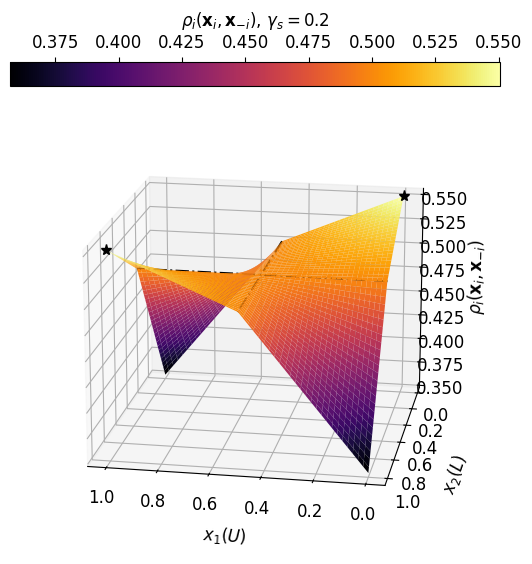

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Global font size (≈12 px)
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# Strategy grids
x1 = np.linspace(0, 1, 200)  # x_1(U)
x2 = np.linspace(0, 1, 200)  # x_2(L)
X1, X2 = np.meshgrid(x1, x2)

# Parameter
gamma_s = 0.2
p = 0.6

# Utility
rho_func = lambda X1, X2, p, gamma_s: (
    0.5
    + (2 * p - 1) / 2 * (1 - 2 * X1) * (1 - 2 * X2)
    - gamma_s * (1 - p) * p * np.abs((1 - 2 * X1) * (1 - 2 * X2))
)
rho = rho_func(X1, X2, p, gamma_s)

# Figure
fig = plt.figure(figsize=(7, 6))

# Main 3D axes (leave room on top)
ax = fig.add_axes([0.05, 0.05, 0.9, 0.75], projection="3d")

surf = ax.plot_surface(X1, X2, rho, cmap="inferno", linewidth=0, antialiased=True)

# Horizontal colorbar above the plot
cax = fig.add_axes([0.15, 0.83, 0.7, 0.04])
cbar = fig.colorbar(surf, cax=cax, orientation="horizontal")

# Add dashed lines at x1=0.5 and x2=0.5
nval = rho_func(0, 0.5, p, gamma_s)
ax.plot([0.5, 0.5], [0, 1], [nval, nval], "k-.", linewidth=1.5, zorder=2)
ax.plot([0, 1], [0.5, 0.5], [nval, nval], "k-.", linewidth=1.5, zorder=2)

# Add points at pure Nash
pureval = rho_func(1, 1, p, gamma_s)
ax.plot([1], [1], [pureval], "k*", markersize=8, zorder=4)
ax.plot([0], [0], [pureval], "k*", markersize=8, zorder=4)

# Put ticks and label above the bar
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.set_label(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$, $\gamma_s=0.2$", labelpad=6)

# Axis labels
ax.set_xlabel(r"$x_1(U)$", labelpad=10)
ax.set_ylabel(r"$x_2(L)$", labelpad=10)
ax.set_zlabel(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$", labelpad=10)

# Camera angle
# elev=17.5, azim=100
ax.view_init(elev=17.5, azim=100)

plt.show()

# Zero-Sum Linear Program

In [13]:
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition


def build_linear_zero_sum_model(
    A_bar: np.ndarray,
) -> pyo.ConcreteModel:

    model = pyo.ConcreteModel()

    # Sets
    model.I = pyo.RangeSet(0, A_bar.shape[0] - 1)
    model.J = pyo.RangeSet(0, A_bar.shape[1] - 1)

    # Parameters
    model.A_bar = pyo.Param(
        model.I,
        model.J,
        initialize={(i, j): A_bar[i, j] for i in model.I for j in model.J},
        domain=pyo.Reals,
    )

    # Variables
    model.x = pyo.Var(model.I, domain=pyo.NonNegativeReals)
    model.pi1 = pyo.Var(domain=pyo.Reals)

    # Objective
    model.obj = pyo.Objective(
        expr=model.pi1,
        sense=pyo.maximize,
    )

    # Constraints
    model.game_value = pyo.Constraint(
        model.J,
        rule=lambda m, j: sum(model.x[i] * m.A_bar[i, j] for i in model.I) >= m.pi1,
    )
    model.simplex_x = pyo.Constraint(expr=sum(model.x[i] for i in model.I) == 1.0)

    # import duals for constraints
    model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    return model


def solve_model(m: pyo.ConcreteModel, solver: str = "cbc"):
    opt = pyo.SolverFactory(solver)
    if opt.available(exception_flag=False):
        res = opt.solve(m, tee=True)
        return res


def build_and_solve(A_bar):
    x_mod = build_linear_zero_sum_model(A_bar)
    solve_model(x_mod)

    # Column strategy y = duals of col constraints
    y = np.array([x_mod.dual[x_mod.game_value[j]] for j in x_mod.J])
    # numerical tidy
    y = np.maximum(y, 0)
    s = y.sum()
    if s > 0:
        y /= s

    # extract
    x = np.array([pyo.value(x_mod.x[i]) for i in x_mod.I])
    y = np.array([pyo.value(y[i]) for i in range(len(y))])

    return {
        "x": x,
        "y": y,
        "game_value": pyo.value(x_mod.obj),
    }

In [ ]:
A1 = np.array([[1, 0], [0, 1]])
A2 = np.array([[0, 1], [1, 0]])
A_list = [A1, A2]

p = 0.5
p = np.array([p, 1 - p])

A_bar = np.array(sum([pk * A for pk, A in zip(p, A_list)]))

print("A_bar =\n", A_bar)

res = build_and_solve(A_bar)
print("x* =", res["x"], " y* =", res["y"], " game value =", res["game_value"])

# Pyomo Complementarity

In [2]:
import numpy as np


def simulate_random_payoffs(
    K: int, n: int, seed: int | None = None, dist: str = "uniform", **kwargs
):
    """
    Simulate K payoff matrices (n x n) for two players.

    Args:
        K: number of scenarios / samples.
        n: action space size for each player (square payoff matrices).
        seed: RNG seed.
        dist: 'uniform' or 'normal'.
        kwargs: extra params: for 'uniform' use low, high; for 'normal' use loc, scale.

    Returns:
        A_list, B_list, p  -- lists of K numpy arrays (shape (n,n)) and scenario probabilities (length K).
    """
    rng = np.random.default_rng(seed)
    if dist == "uniform":
        low = kwargs.get("low", 0.0)
        high = kwargs.get("high", 1.0)
        A_list = [rng.uniform(low, high, (n, n)) for _ in range(K)]
        B_list = [rng.uniform(low, high, (n, n)) for _ in range(K)]
    elif dist == "normal":
        loc = kwargs.get("loc", 0.0)
        scale = kwargs.get("scale", 1.0)
        A_list = [rng.normal(loc, scale, (n, n)) for _ in range(K)]
        B_list = [rng.normal(loc, scale, (n, n)) for _ in range(K)]
    else:
        raise ValueError("Unsupported dist. Choose 'uniform' or 'normal'.")

    p = rng.dirichlet(np.ones(K))
    return A_list, B_list, p


A_list, B_list, p = simulate_random_payoffs(
    K=50, n=2, seed=42, dist="uniform", low=0, high=1
)
gamma = 0.5

## MSD

In [17]:
# Two-player mean-semi-deviation (MSD) risk-aware bimatrix game as a Multilinear Complementarity Problem (MCP)
# Requires: pyomo (>=6), plus PATH ('path' or 'pathmcp') or IPOPT with mpec.simple_nonlinear transform.

import time
from typing import List
import numpy as np
import pyomo.environ as pyo
from pyomo.mpec import Complementarity, complements
from pyomo.opt import SolverStatus, TerminationCondition


def build_model(
    A_list: List[np.ndarray], B_list: List[np.ndarray], p: np.ndarray, gamma: float
) -> pyo.ConcreteModel:
    K = len(A_list)
    n1, n2 = A_list[0].shape
    assert all(Ak.shape == (n1, n2) for Ak in A_list)
    assert all(Bk.shape == (n1, n2) for Bk in B_list)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    m = pyo.ConcreteModel()

    # Sets
    m.I = pyo.RangeSet(0, n1 - 1)
    m.J = pyo.RangeSet(0, n2 - 1)
    m.K = pyo.RangeSet(0, K - 1)

    # Params (store as dicts for Pyomo)
    # Converts payoff matrices to 3D arrays
    def to_param_3d(lst):
        data = {}
        for k, M in enumerate(lst):
            for i in range(n1):
                for j in range(n2):
                    data[(k, i, j)] = float(M[i, j])
        return data

    m.p = pyo.Param(
        m.K, initialize={k: float(p[k]) for k in range(K)}, within=pyo.NonNegativeReals
    )
    m.gamma = pyo.Param(initialize=float(gamma), within=pyo.NonNegativeReals)
    m.A = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(A_list))
    m.B = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(B_list))

    # Abar, Bbar
    def Abar_rule(m, i, j):
        return sum(m.p[k] * m.A[k, i, j] for k in m.K)

    def Bbar_rule(m, i, j):
        return sum(m.p[k] * m.B[k, i, j] for k in m.K)

    m.Abar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Abar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )
    m.Bbar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Bbar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )

    # Variables
    m.x = pyo.Var(m.I, domain=pyo.NonNegativeReals)  # strategies
    m.y = pyo.Var(m.J, domain=pyo.NonNegativeReals)
    m.alpha1 = pyo.Var(domain=pyo.Reals)  # values
    m.alpha2 = pyo.Var(domain=pyo.Reals)
    m.lam1 = pyo.Var(
        m.K, bounds=lambda m, k: (0.0, pyo.value(m.gamma) * pyo.value(m.p[k]))
    )
    m.lam2 = pyo.Var(
        m.K, bounds=lambda m, k: (0.0, pyo.value(m.gamma) * pyo.value(m.p[k]))
    )
    m.z1 = pyo.Var(m.K, domain=pyo.NonNegativeReals)  # z >= 0
    m.z2 = pyo.Var(m.K, domain=pyo.NonNegativeReals)

    # Non-zero solution constraint to avoid trivial all-zero solution if using the non-simplex formulation
    # m.nonzero_x = pyo.Constraint(expr=sum(m.x[i] for i in m.I) >= 1e-6)
    # m.nonzero_y = pyo.Constraint(expr=sum(m.y[j] for j in m.J) >= 1e-6)
    # m.nonzero_z1 = pyo.Constraint(expr=sum(m.z1[k] for k in m.K) >= 1e-6)
    # m.nonzero_z2 = pyo.Constraint(expr=sum(m.z2[k] for k in m.K) >= 1e-6)

    # Simplex equalities
    m.simplex_x = pyo.Constraint(expr=sum(m.x[i] for i in m.I) == 1.0)
    m.simplex_y = pyo.Constraint(expr=sum(m.y[j] for j in m.J) == 1.0)

    # Helper expressions
    # Player 1 row values: v1[i] = Abar[i,:] y + sum_k lam1[k]*(A^k - Abar)[i,:] y
    def v1_rule(m, i):
        base = sum(m.Abar[i, j] * m.y[j] for j in m.J)
        dev = sum(
            m.lam1[k] * sum((m.A[k, i, j] - m.Abar[i, j]) * m.y[j] for j in m.J)
            for k in m.K
        )
        return base + dev

    m.v1 = pyo.Expression(m.I, rule=v1_rule)

    # Player 2 column values: v2[j] = x^T Bbar[:,j] + sum_k lam2[k]* x^T (B^k - Bbar)[:,j]
    def v2_rule(m, j):
        base = sum(m.x[i] * m.Bbar[i, j] for i in m.I)
        dev = sum(
            m.lam2[k] * sum(m.x[i] * (m.B[k, i, j] - m.Bbar[i, j]) for i in m.I)
            for k in m.K
        )
        return base + dev

    m.v2 = pyo.Expression(m.J, rule=v2_rule)

    # Scenario residuals:
    # r1[k] = x^T (A^k - Abar) y
    def r1_rule(m, k):
        return sum(
            m.x[i] * sum((m.A[k, i, j] - m.Abar[i, j]) * m.y[j] for j in m.J)
            for i in m.I
        )

    m.r1 = pyo.Expression(m.K, rule=r1_rule)

    # r2[k] = x^T (B^k - Bbar) y
    def r2_rule(m, k):
        return sum(
            m.x[i] * sum((m.B[k, i, j] - m.Bbar[i, j]) * m.y[j] for j in m.J)
            for i in m.I
        )

    m.r2 = pyo.Expression(m.K, rule=r2_rule)

    # Complementarity conditions
    # 0 <= x_i ⟂ alpha1 - v1_i >= 0
    m.comp_x = Complementarity(
        m.I, rule=lambda m, i: complements(m.x[i] >= 0, m.alpha1 - m.v1[i] >= 0)
    )
    # 0 <= y_j ⟂ alpha2 - v2_j >= 0
    m.comp_y = Complementarity(
        m.J, rule=lambda m, j: complements(m.y[j] >= 0, m.alpha2 - m.v2[j] >= 0)
    )
    # 0 <= lam1_k ⟂ r1_k + z1_k >= 0 ; 0 <= gamma p_k - lam1_k ⟂ z1_k >= 0
    m.comp_r1 = Complementarity(
        m.K, rule=lambda m, k: complements(m.lam1[k] >= 0, m.r1[k] + m.z1[k] >= 0)
    )
    m.comp_z1 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.gamma * m.p[k] - m.lam1[k] >= 0, m.z1[k] >= 0),
    )
    # Player 2 analogues
    m.comp_r2 = Complementarity(
        m.K, rule=lambda m, k: complements(m.lam2[k] >= 0, m.r2[k] + m.z2[k] >= 0)
    )
    m.comp_z2 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.gamma * m.p[k] - m.lam2[k] >= 0, m.z2[k] >= 0),
    )

    return m


def solve_model(
    m: pyo.ConcreteModel,
    solver: str = "pathampl",
    fallback_solver: str | None = None,
    tee: bool = False,
):

    acceptable_terminations = {
        TerminationCondition.optimal,
        TerminationCondition.locallyOptimal,
        TerminationCondition.feasible,
    }

    def solve_and_load(opt, model):
        res = opt.solve(model, tee=tee, load_solutions=False)
        status = res.solver.status
        termination = res.solver.termination_condition
        if (
            status in {SolverStatus.ok, SolverStatus.warning}
            and termination in acceptable_terminations
        ):
            model.solutions.load_from(res)
            return res
        raise RuntimeError(
            f"{opt.name} failed with status={status}, termination={termination}"
        )

    def transform_and_solve(model):
        transformed_model = model.clone()
        pyo.TransformationFactory("mpec.simple_nonlinear").apply_to(transformed_model)
        opt = pyo.SolverFactory("ipopt")
        assert opt.available(exception_flag=False), "Neither PATH nor IPOPT available."
        res = solve_and_load(opt, transformed_model)
        return res, transformed_model

    opt = pyo.SolverFactory(solver)
    start = time.perf_counter()
    if solver == "ipopt":
        res, solved_model = transform_and_solve(m)
        elapsed = time.perf_counter() - start
        return res, elapsed, solved_model

    if opt.available(exception_flag=False):
        fallback_model = m.clone()
        try:
            res = solve_and_load(opt, m)
            solved_model = m
        except Exception as e:
            if fallback_solver != "ipopt":
                raise
            res, solved_model = transform_and_solve(fallback_model)
            print(f"Solved using ipopt because {e}")

        elapsed = time.perf_counter() - start
        return res, elapsed, solved_model

    if fallback_solver != "ipopt":
        raise RuntimeError(f"Solver {solver!r} is not available and fallback_solver={fallback_solver!r}.")
    res, solved_model = transform_and_solve(m)
    elapsed = time.perf_counter() - start
    return res, elapsed, solved_model


def build_and_solve(
    A_list,
    B_list,
    p,
    gamma,
    solver="pathampl",
    fallback_solver=None,
    tee=False,
):
    m = build_model(A_list, B_list, p, gamma)
    res, solve_time, m = solve_model(
        m, solver=solver, fallback_solver=fallback_solver, tee=tee
    )
    # extract
    x = np.array([pyo.value(m.x[i]) for i in m.I])
    y = np.array([pyo.value(m.y[j]) for j in m.J])
    alpha1 = float(pyo.value(m.alpha1))
    alpha2 = float(pyo.value(m.alpha2))
    lam1 = np.array([pyo.value(m.lam1[k]) for k in m.K])
    lam2 = np.array([pyo.value(m.lam2[k]) for k in m.K])
    z1 = np.array([pyo.value(m.z1[k]) for k in m.K])
    z2 = np.array([pyo.value(m.z2[k]) for k in m.K])
    return {
        "x": x,
        "y": y,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "lam1": lam1,
        "z1": z1,
        "lam2": lam2,
        "z2": z2,
        "time": solve_time,
    }


def path_MCP_game_result(
    A_payoffs,
    B_payoffs,
    gamma,
    p=None,
    verbose=False,
    solver="pathampl",
    fallback_solver=None,
    tee=False,
):

    if p is None:
        p = 1 / len(A_payoffs)
        p = np.array([p for _ in range(len(A_payoffs))])

    res = build_and_solve(
        A_payoffs,
        B_payoffs,
        p,
        gamma,
        solver=solver,
        fallback_solver=fallback_solver,
        tee=tee,
    )

    if verbose:

        print("=" * 50 + "PATH Result" + "=" * 50)

        print("x* =", res["x"].round(3), " y* =", res["y"].round(3))
        print("alpha1 =", res["alpha1"], " alpha2 =", res["alpha2"])

        print(f"{p=}")

        A_bar = np.array(sum([pk * A for pk, A in zip(p, A_payoffs)]))
        B_bar = np.array(sum([pk * B for pk, B in zip(p, B_payoffs)]))

        dev1 = [(A - A_bar) for A in A_payoffs]
        dev2 = [(B - B_bar) for B in B_payoffs]

        print("-" * 50 + "Player 1" + "-" * 50)
        print("A_bar =\n", A_bar)
        print("lam1 =", res["lam1"], " z1 =", res["z1"])
        print(f"x@dev1@y = {np.round(res["x"]@np.stack(dev1)@res["y"], 3)}")
        print(
            "(A_bar + sum(lam1k*dk)) =\n",
            (A_bar + sum(lam * dk for lam, dk in zip(res["lam1"], dev1))),
        )
        print(
            "(A_bar + sum(lam1k*dk))@y =\n",
            (A_bar + sum(lam * dk for lam, dk in zip(res["lam1"], dev1))) @ res["y"],
        )

        print("-" * 50 + "Player 2" + "-" * 50)
        print("B_bar =\n", B_bar)
        print("lam2 =", res["lam2"], " z2 =", res["z2"])
        print(f"x@dev2@y = {np.round(res["x"]@np.stack(dev2)@res["y"], 3)}")
        print(
            "(B_bar + sum(lam2k*dk)) =\n",
            (B_bar + sum(lam * dk for lam, dk in zip(res["lam2"], dev2))),
        )
        print(
            "x@(B_bar + sum(lam2k*dk)) =\n",
            res["x"] @ (B_bar + sum(lam * dk for lam, dk in zip(res["lam2"], dev2))),
        )

    return res

In [18]:
path_MCP_game_result(A_list, B_list, gamma, p, False)

Solved using ipopt because asl failed with status=error, termination=internalSolverError


{'x': array([0.62860968, 0.37139032]),
 'y': array([0.01490912, 0.98509088]),
 'alpha1': 0.467150926392094,
 'alpha2': 0.4420735965506752,
 'lam1': array([2.07457995e-07, 1.37813182e-08, 5.51896125e-08, 6.77267519e-08,
        4.00073034e-03, 1.26186758e-07, 1.63710726e-04, 2.08904886e-08,
        1.96970878e-04, 1.88196754e-07, 4.77144078e-08, 5.92774214e-08,
        5.44212920e-03, 2.97818582e-08, 2.01076136e-03, 8.71274944e-08,
        2.02940370e-02, 7.37946128e-04, 8.32191155e-05, 3.08161672e-08,
        9.08070765e-03, 5.74774973e-02, 1.07633001e-07, 1.30217129e-02,
        7.81449374e-04, 1.96113491e-08, 1.41540516e-07, 4.83094038e-08,
        3.62030802e-08, 3.42830452e-08, 1.22007064e-07, 7.67799247e-03,
        3.05127828e-08, 4.36470158e-03, 2.08105523e-02, 4.27010762e-07,
        1.08952092e-02, 2.34378361e-03, 7.63713688e-08, 3.19550219e-08,
        8.44952965e-08, 2.35669958e-07, 2.08392749e-08, 6.90675807e-08,
        1.37552580e-08, 3.52546155e-08, 1.18258718e-03, 3.981

## CVaR

In [33]:
# Two-player CVaR game
# Requires: pyomo (>=6), plus PATH ('path' or 'pathmcp') or IPOPT with mpec.simple_nonlinear transform.

from typing import List
import numpy as np
import pyomo.environ as pyo
from pyomo.mpec import Complementarity, complements


def build_model_cVar(
    A_list: List[np.ndarray],
    B_list: List[np.ndarray],
    p: np.ndarray,
    gamma: float,
    alpha: float,
) -> pyo.ConcreteModel:
    K = len(A_list)
    n1, n2 = A_list[0].shape
    assert all(Ak.shape == (n1, n2) for Ak in A_list)
    assert all(Bk.shape == (n1, n2) for Bk in B_list)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    m = pyo.ConcreteModel()

    # Sets
    m.I = pyo.RangeSet(0, n1 - 1)
    m.J = pyo.RangeSet(0, n2 - 1)
    m.K = pyo.RangeSet(0, K - 1)

    # Params (store as dicts for Pyomo)
    # Converts payoff matrices to 3D arrays
    def to_param_3d(lst):
        data = {}
        for k, M in enumerate(lst):
            for i in range(n1):
                for j in range(n2):
                    data[(k, i, j)] = float(M[i, j])
        return data

    m.p = pyo.Param(
        m.K, initialize={k: float(p[k]) for k in range(K)}, within=pyo.NonNegativeReals
    )
    m.gamma = pyo.Param(initialize=float(gamma), within=pyo.NonNegativeReals)
    m.alpha = pyo.Param(initialize=float(alpha), within=pyo.NonNegativeReals)
    m.A = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(A_list))
    m.B = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(B_list))

    # Abar, Bbar
    def Abar_rule(m, i, j):
        return sum(m.p[k] * m.A[k, i, j] for k in m.K)

    def Bbar_rule(m, i, j):
        return sum(m.p[k] * m.B[k, i, j] for k in m.K)

    m.Abar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Abar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )
    m.Bbar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Bbar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )

    # Variables
    m.x = pyo.Var(m.I, domain=pyo.NonNegativeReals)  # strategies
    m.y = pyo.Var(m.J, domain=pyo.NonNegativeReals)
    m.alpha1 = pyo.Var(domain=pyo.Reals)  # values
    m.alpha2 = pyo.Var(domain=pyo.Reals)
    m.lam1 = pyo.Var(
        m.K,
        bounds=lambda m, k: (
            0.0,
            pyo.value(m.gamma) / pyo.value(m.alpha) * pyo.value(m.p[k]),
        ),
    )
    m.lam2 = pyo.Var(
        m.K,
        bounds=lambda m, k: (
            0.0,
            pyo.value(m.gamma) / pyo.value(m.alpha) * pyo.value(m.p[k]),
        ),
    )
    m.nu1 = pyo.Var(m.K, domain=pyo.NonNegativeReals)  # nu >= 0
    m.nu2 = pyo.Var(m.K, domain=pyo.NonNegativeReals)

    m.z1 = pyo.Var(domain=pyo.Reals)  # VaR for player 1
    m.z2 = pyo.Var(domain=pyo.Reals)  # VaR for player 2

    # Simplex equalities
    m.simplex_x = pyo.Constraint(expr=sum(m.x[i] for i in m.I) == 1.0)
    m.simplex_y = pyo.Constraint(expr=sum(m.y[j] for j in m.J) == 1.0)

    # cVar equalities
    m.cVar_x = pyo.Constraint(expr=sum(m.lam1[i] for i in m.K) == pyo.value(m.gamma))
    m.cVar_y = pyo.Constraint(expr=sum(m.lam2[i] for i in m.K) == pyo.value(m.gamma))

    # Helper expressions
    # Player 1 row values: v1[i] = (1-gamma)Abar[i,:] y + sum_k lam1[k]*A^k[i,:] y
    def v1_rule(m, i):
        base = sum(m.Abar[i, j] * m.y[j] for j in m.J)
        cVar = sum(m.lam1[k] * sum(m.A[k, i, j] * m.y[j] for j in m.J) for k in m.K)
        return (1 - pyo.value(m.gamma)) * base + cVar

    m.v1 = pyo.Expression(m.I, rule=v1_rule)

    # Player 2 column values: v2[j] = (1-gamma) x^T Bbar[:,j] + sum_k lam2[k]* x^T B^k[:,j]
    def v2_rule(m, j):
        base = sum(m.x[i] * m.Bbar[i, j] for i in m.I)
        cVar = sum(m.lam2[k] * sum(m.x[i] * m.B[k, i, j] for i in m.I) for k in m.K)
        return (1 - pyo.value(m.gamma)) * base + cVar

    m.v2 = pyo.Expression(m.J, rule=v2_rule)

    # Scenario residuals:
    # r1[k] = x^T A^k y - z
    def r1_rule(m, k):
        return sum(m.x[i] * sum(m.A[k, i, j] * m.y[j] for j in m.J) for i in m.I) - m.z1

    m.r1 = pyo.Expression(m.K, rule=r1_rule)

    # r2[k] = x^T B^k y
    def r2_rule(m, k):
        return sum(m.x[i] * sum(m.B[k, i, j] * m.y[j] for j in m.J) for i in m.I) - m.z2

    m.r2 = pyo.Expression(m.K, rule=r2_rule)

    # Complementarity conditions
    # 0 <= x_i ⟂ alpha1 - v1_i >= 0
    m.comp_x = Complementarity(
        m.I, rule=lambda m, i: complements(m.x[i] >= 0, m.alpha1 - m.v1[i] >= 0)
    )
    # 0 <= y_j ⟂ alpha2 - v2_j >= 0
    m.comp_y = Complementarity(
        m.J, rule=lambda m, j: complements(m.y[j] >= 0, m.alpha2 - m.v2[j] >= 0)
    )
    # 0 <= lam1_k ⟂ r1_k - z1 + nu1_k >= 0 ; 0 <= gamma p_k/alpha - lam1_k ⟂ nu1_k >= 0
    m.comp_r1 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.lam1[k] >= 0, m.r1[k] + m.nu1[k] >= 0),
    )
    m.comp_z1 = Complementarity(
        m.K,
        rule=lambda m, k: complements(
            m.gamma * m.p[k] / m.alpha - m.lam1[k] >= 0, m.nu1[k] >= 0
        ),
    )
    # Player 2 analogues
    m.comp_r2 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.lam2[k] >= 0, m.r2[k] + m.nu2[k] >= 0),
    )
    m.comp_z2 = Complementarity(
        m.K,
        rule=lambda m, k: complements(
            m.gamma * m.p[k] / m.alpha - m.lam2[k] >= 0, m.nu2[k] >= 0
        ),
    )

    return m


def build_and_solve_cVar(A_list, B_list, p, gamma, alpha, solver="pathampl"):
    m = build_model_cVar(A_list, B_list, p, gamma, alpha)
    solve_model(m, solver=solver)
    # extract
    x = np.array([pyo.value(m.x[i]) for i in m.I])
    y = np.array([pyo.value(m.y[j]) for j in m.J])
    alpha = float(pyo.value(m.alpha))
    alpha1 = float(pyo.value(m.alpha1))
    alpha2 = float(pyo.value(m.alpha2))
    lam1 = np.array([pyo.value(m.lam1[k]) for k in m.K])
    lam2 = np.array([pyo.value(m.lam2[k]) for k in m.K])
    nu1 = np.array([pyo.value(m.nu1[k]) for k in m.K])
    nu2 = np.array([pyo.value(m.nu2[k]) for k in m.K])
    z1 = float(pyo.value(m.z1))
    z2 = float(pyo.value(m.z2))

    return {
        "x": x,
        "y": y,
        "alpha": alpha,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "lam1": lam1,
        "nu1": nu1,
        "z1": z1,
        "lam2": lam2,
        "nu2": nu2,
        "z2": z2,
    }


def path_MCP_game_result_cVar(
    A_payoffs, B_payoffs, gamma, alpha, p=None, verbose=False
):

    if p is None:
        p = 1 / len(A_payoffs)
        p = np.array([p for _ in range(len(A_payoffs))])

    res = build_and_solve_cVar(A_payoffs, B_payoffs, p, gamma, alpha)

    if verbose:

        print("=" * 50 + "PATH Result" + "=" * 50)

        print("x* =", res["x"].round(3), " y* =", res["y"].round(3))
        print("alpha1 =", res["alpha1"], " alpha2 =", res["alpha2"])

        print(f"{p=}")

    return res

In [34]:
gamma = 0.5
alpha = 0.05

res = path_MCP_game_result_cVar(A_list, B_list, gamma, alpha=alpha, p=p, verbose=False)
res

'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_x[0] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_x[1] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_y[0] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_y[1] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstrai

{'x': array([0.50917217, 0.49082783]),
 'y': array([0.51097083, 0.48902917]),
 'alpha': 0.05,
 'alpha1': 0.397536229180446,
 'alpha2': 0.3471895984143381,
 'lam1': array([1.45395161e-08, 1.70763756e-08, 4.40952135e-08, 2.72795134e-08,
        3.01669863e-08, 1.24280949e-08, 1.11241215e-07, 1.82503516e-08,
        3.31712262e-07, 1.31144995e-07, 2.31939864e-08, 2.20208197e-08,
        1.08842727e-01, 1.27629502e-08, 2.07765670e-06, 1.91721879e-08,
        3.07113742e-08, 1.47602819e-02, 1.55066733e-07, 2.34725071e-08,
        3.03540239e-08, 1.02054711e-01, 1.25631078e-07, 5.34066301e-08,
        1.15552291e-07, 1.37798499e-08, 2.45842091e-08, 6.88590833e-08,
        4.01225847e-08, 1.78259155e-08, 5.49412238e-08, 1.53560601e-01,
        5.33055577e-08, 9.07497940e-08, 2.17965050e-08, 1.88241617e-08,
        8.27574349e-08, 2.67576889e-08, 1.52904014e-07, 2.01548232e-08,
        2.69137984e-06, 1.76001275e-08, 3.06782664e-08, 2.09173545e-07,
        1.17067616e-08, 1.62844835e-08, 3.791

# Fischer-Burmeister (FB) NCP Solver

In [35]:
# Two-player MSD risk-aware game solved as an MCP via a Fischer–Burmeister (FB) NCP solver.
# This implements the multilinear complementarity program directly (not an LCP).
# It uses SciPy's least_squares to drive the FB residual to zero with simple bounds.

import numpy as np
from typing import List, Dict, Any

try:
    from scipy.optimize import least_squares

    SCIPY_OK = True
except Exception:
    SCIPY_OK = False


def fb(a, b):
    """Fischer–Burmeister function φ(a,b) = sqrt(a^2+b^2) - (a+b). Zero iff a>=0, b>=0, a*b=0."""
    return np.sqrt(a * a + b * b) - (a + b)


def pack_vars(x, y, lam1, z1, lam2, z2, alpha1, alpha2):
    return np.concatenate([x, y, lam1, z1, lam2, z2, np.array([alpha1, alpha2])])


def unpack_vars(v, n1, n2, K):
    x = v[0:n1]
    y = v[n1 : n1 + n2]
    lam1 = v[n1 + n2 : n1 + n2 + K]
    z1 = v[n1 + n2 + K : n1 + n2 + 2 * K]
    lam2 = v[n1 + n2 + 2 * K : n1 + n2 + 3 * K]
    z2 = v[n1 + n2 + 3 * K : n1 + n2 + 4 * K]
    alpha1 = v[-2]
    alpha2 = v[-1]
    return x, y, lam1, z1, lam2, z2, alpha1, alpha2


def mcp_residual(v, A_list, B_list, p, gamma):
    """Build FB residual vector F(v)=0 for the MSD bimatrix MCP."""
    n1, n2 = A_list[0].shape
    K = len(A_list)
    x, y, lam1, z1, lam2, z2, alpha1, alpha2 = unpack_vars(v, n1, n2, K)

    # Abar, Bbar
    Abar = sum(pk * Ak for pk, Ak in zip(p, A_list))
    Bbar = sum(pk * Bk for pk, Bk in zip(p, B_list))

    # Player 1: row values v1_l(y, lam1)
    # v1_l = (Abar_l + Σ λ_k (A^k_l - Abar_l)) y == Abar_l y + Σ λ_k (A^k_l - Abar_l) y
    # We'll compute matrix V1 := Abar + Σ λ_k (A^k - Abar)  so that v1 = V1 y
    V1 = (
        Abar.copy()
    )  # start from Abar then add weighted deviations (since stationarity uses Abar)
    for k in range(K):
        V1 += lam1[k] * (A_list[k] - Abar)
    v1_rows = V1 @ y  # shape (n1,)

    # Player 2: column values v2_c(x, lam2) with V2^T x
    V2 = Bbar.copy()
    for k in range(K):
        V2 += lam2[k] * (B_list[k] - Bbar)
    v2_cols = V2.T @ x  # shape (n2,)

    # Scenario residuals
    r1 = np.array([x @ ((A_list[k] - Abar) @ y) for k in range(K)])
    r2 = np.array([x @ ((B_list[k] - Bbar) @ y) for k in range(K)])

    # Build FB residuals
    res = []

    # (i) Strategy–value complementarity
    # 0 <= x ⊥ (alpha1 - v1_rows) >= 0
    res.extend(fb(x, alpha1 - v1_rows))
    # 0 <= y ⊥ (alpha2 - v2_cols) >= 0
    res.extend(fb(y, alpha2 - v2_cols))

    # (ii) MSD residual pairs
    # For player 1:
    # 0 <= lam1 ⊥ (r1 - z1) >= 0
    res.extend(fb(lam1, r1 - z1))
    # 0 <= gamma*p - lam1 ⊥ (-z1) >= 0
    res.extend(fb(gamma * p - lam1, -z1))

    # For player 2:
    res.extend(fb(lam2, r2 - z2))
    res.extend(fb(gamma * p - lam2, -z2))

    # (iii) Simplex equalities (sum x = 1, sum y = 1)
    res.append(x.sum() - 1.0)
    res.append(y.sum() - 1.0)

    return np.array(res, dtype=float)


def solve_mcp_msd_bimatrix(
    A_list: List[np.ndarray],
    B_list: List[np.ndarray],
    p: np.ndarray,
    gamma: float,
    x0: np.ndarray = None,
    y0: np.ndarray = None,
    max_nfev: int = 20000,
    verbose: bool = True,
) -> Dict[str, Any]:
    """Solve the MSD bimatrix MCP via FB least-squares."""
    assert SCIPY_OK, "SciPy is required for this solver."
    K = len(A_list)
    n1, n2 = A_list[0].shape
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    # Initial strategies
    if x0 is None:
        x0 = np.ones(n1) / n1
    if y0 is None:
        y0 = np.ones(n2) / n2

    # Initialize lambdas, z, alphas
    lam1 = np.zeros(K)
    lam2 = np.zeros(K)
    z1 = np.zeros(K)
    z2 = np.zeros(K)

    # Reasonable alpha in [0,1+gamma]: expected value + gamma * expected downside (<= gamma)
    Abar = sum(pk * Ak for pk, Ak in zip(p, A_list))
    Bbar = sum(pk * Bk for pk, Bk in zip(p, B_list))
    alpha1 = float(x0 @ (Abar @ y0))
    alpha2 = float(x0 @ (Bbar @ y0))

    v0 = pack_vars(x0, y0, lam1, z1, lam2, z2, alpha1, alpha2)

    # Bounds: x,y in [0,1]; lam in [0, gamma p_k]; z in (-inf, 0]; alpha in [-10, 10]
    lb = np.concatenate(
        [
            np.zeros(n1),
            np.zeros(n2),
            np.zeros(K),
            -np.full(K, np.inf),
            np.zeros(K),
            -np.full(K, np.inf),
            np.array([-np.inf, -np.inf]),
        ]
    )
    ub = np.concatenate(
        [
            np.ones(n1),
            np.ones(n2),
            gamma * p,
            np.zeros(K),
            gamma * p,
            np.zeros(K),
            np.array([np.inf, np.inf]),
        ]
    )

    fun = lambda v: mcp_residual(v, A_list, B_list, p, gamma)
    res = least_squares(
        fun,
        v0,
        jac="3-point",
        bounds=(lb, ub),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
        max_nfev=max_nfev,
        verbose=2 if verbose else 0,
    )

    v_star = res.x
    x, y, lam1, z1, lam2, z2, alpha1, alpha2 = unpack_vars(v_star, n1, n2, K)

    out = {
        "success": res.success,
        "status": res.status,
        "message": res.message,
        "residual_norm": np.linalg.norm(res.fun),
        "x": x,
        "y": y,
        "alpha1": float(alpha1),
        "alpha2": float(alpha2),
        "lam1": lam1,
        "z1": z1,
        "lam2": lam2,
        "z2": z2,
        "nfev": res.nfev,
    }
    return out

In [36]:
sol = solve_mcp_msd_bimatrix(A_list, B_list, p, gamma, verbose=False)
print("\n=== MCP Result ===")
for k, v in sol.items():
    if isinstance(v, np.ndarray):
        print(f"{k} = {np.round(v, 6)}")
    else:
        print(f"{k} = {v}")


=== MCP Result ===
success = True
status = 3
message = `xtol` termination condition is satisfied.
residual_norm = 0.01686495723869609
x = [0.347653 0.652167]
y = [0.422629 0.577348]
alpha1 = 0.48595746952325747
alpha2 = 0.419412310652538
lam1 = [0.0000e+00 0.0000e+00 0.0000e+00 2.4670e-03 0.0000e+00 0.0000e+00
 1.6400e-04 0.0000e+00 1.9700e-04 8.5400e-03 5.5000e-04 2.9820e-03
 5.4420e-03 0.0000e+00 2.0110e-03 0.0000e+00 2.0294e-02 6.3500e-04
 8.3000e-05 0.0000e+00 9.0810e-03 5.5996e-02 3.0620e-03 1.2854e-02
 0.0000e+00 4.3300e-04 1.8524e-02 2.0656e-02 0.0000e+00 6.6400e-04
 7.9000e-04 7.6780e-03 0.0000e+00 4.3650e-03 2.0811e-02 0.0000e+00
 1.0716e-02 0.0000e+00 1.0188e-02 0.0000e+00 1.3831e-02 0.0000e+00
 1.1029e-02 4.4280e-03 0.0000e+00 1.6250e-03 1.1830e-03 1.0160e-03
 6.1390e-03 3.3090e-03]
z1 = [-0.00000e+00 -0.00000e+00 -5.00000e-06 -4.57540e-02 -5.00000e-06
 -0.00000e+00 -2.14709e-01 -0.00000e+00 -1.90283e-01 -8.39600e-02
 -0.00000e+00 -1.41010e-02 -3.27075e-01 -0.00000e+00 -2.5

# Experiments

Generate systematic examples and compare OOS performance across different game structures and risk levels.

In [516]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [517]:
# Systematic OOS evaluation across gamma values
def evaluate_oos_across_gamma(
    A_scenarios,
    B_scenarios,
    p_arr,
    A_large_n,
    B_large_n,
    gamma_values,
    verbose=False,
    func=solve_mcp_msd_bimatrix,
    **kwargs,
):
    results = []
    for i, p in enumerate(p_arr):
        if len(A_scenarios) != len(B_scenarios):
            raise ValueError("A and B must have the same length.")

        A_bar = sum(pk * Ak for pk, Ak in zip(p, A_scenarios))
        B_bar = sum(pk * Bk for pk, Bk in zip(p, B_scenarios))

        for gamma in gamma_values:
            sol = func(
                list(A_scenarios),
                list(B_scenarios),
                p=p,
                gamma=gamma,
                verbose=verbose,
                **kwargs,
            )

            x_eq = sol["x"]
            y_eq = sol["y"]

            in_sample_payoff1 = float(x_eq @ A_bar @ y_eq)
            in_sample_payoff2 = float(x_eq @ B_bar @ y_eq)

            oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
            oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)

            results.append(
                {
                    "sample": i,
                    "gamma": gamma,
                    "x": np.round(x_eq, 3),
                    "y": np.round(y_eq, 3),
                    "in_sample_payoff1": in_sample_payoff1,
                    "in_sample_payoff2": in_sample_payoff2,
                    "oos_mean1": float(oos_payoffs1.mean()),
                    "oos_std1": float(oos_payoffs1.std()),
                    "oos_min1": float(oos_payoffs1.min()),
                    "oos_mean2": float(oos_payoffs2.mean()),
                    "oos_std2": float(oos_payoffs2.std()),
                    "oos_min2": float(oos_payoffs2.min()),
                }
            )
    return pd.DataFrame(results)

## Coordination game

In [518]:
import numpy as np

small_sample_size = 5
n_small_sample = 100
n_large_sample = 10000

rng = np.random.default_rng(444)
scenarios = rng.binomial(1, 0.6, (n_small_sample, small_sample_size))
large_n = rng.binomial(1, 0.6, n_large_sample)


def coordination_payoff(state):

    if state:
        return np.array([[1, 0], [0, 1]])
    else:
        return np.array([[0, 1], [1, 0]])


A_payoffs = [coordination_payoff(0), coordination_payoff(1)]
B_payoffs = A_payoffs.copy()

p_1 = (scenarios.sum(axis=1) / 5).reshape(-1, 1)
p_hat = np.concat([1 - p_1, p_1], axis=1)

A_large_n = np.array([coordination_payoff(s) for s in large_n])
B_large_n = A_large_n.copy()

In [519]:
res = evaluate_oos_across_gamma(
    A_payoffs,
    B_payoffs,
    p_hat,
    A_large_n,
    B_large_n,
    gamma_values=np.linspace(0, 1, 11),
    verbose=False,
    func=path_MCP_game_result,
)
res.head()

/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:37: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:37: RuntimeWarning: overflow encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:37: RuntimeWarning: invalid value encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:38: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:38: RuntimeWarning: overflow encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py

,sample,gamma,x,y,in_sample_payoff1,in_sample_payoff2,oos_mean1,oos_std1,oos_min1,oos_mean2,oos_std2,oos_min2
0,0,0.0,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,0.000000e+00,0.5,0.5,0.000000e+00,0.5
1,0,0.1,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,1.110223e-16,0.5,0.5,1.110223e-16,0.5
2,0,0.2,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,2.220446e-16,0.5,0.5,2.220446e-16,0.5
3,0,0.3,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,1.110223e-16,0.5,0.5,1.110223e-16,0.5
4,0,0.4,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,1.110223e-16,0.5,0.5,1.110223e-16,0.5


## Prisoner's Dilemma

In [520]:
import numpy as np

small_sample_size = 5
n_small_sample = 100
n_large_sample = 10000

rng = np.random.default_rng(444)
scenarios = rng.uniform(0, 1, (n_small_sample, small_sample_size))
large_n = rng.uniform(0, 1, n_large_sample)


def dilemma_payoff(s):

    if s == 0:  # Typical prisoner's dilemma
        return np.array([[3, 0], [5, 1]])
    elif s == 1:  # Mutually-assured destruction
        return np.array([[3, 0], [0, 0]])
    else:  # External evidence
        return np.array([[0, 0], [0, 1]])


def create_state_array(scenarios):

    out = scenarios.copy()
    out[scenarios < 1 / 2] = 0
    out[(scenarios >= 1 / 2) & (scenarios < 3 / 4)] = 1
    out[scenarios >= 3 / 4] = 2

    return out


scenario_states = create_state_array(scenarios)
p_hat_counts = np.array(
    [
        (scenario_states == 0).sum(axis=1),
        (scenario_states == 1).sum(axis=1),
        (scenario_states == 2).sum(axis=1),
    ]
).transpose()
p_hat = p_hat_counts / small_sample_size

A_payoffs = [dilemma_payoff(0), dilemma_payoff(1), dilemma_payoff(2)]
B_payoffs = [A_payoff.copy().transpose() for A_payoff in A_payoffs]

A_large_n = create_state_array(large_n)
A_large_n = np.array([dilemma_payoff(s) for s in A_large_n])
B_large_n = A_large_n.copy().transpose(0, 2, 1)

A_payoffs, B_payoffs

([array([[3, 0],
         [5, 1]]),
  array([[3, 0],
         [0, 0]]),
  array([[0, 0],
         [0, 1]])],
 [array([[3, 5],
         [0, 1]]),
  array([[3, 0],
         [0, 0]]),
  array([[0, 0],
         [0, 1]])])

In [521]:
res = evaluate_oos_across_gamma(
    A_payoffs,
    B_payoffs,
    p_hat,
    A_large_n,
    B_large_n,
    gamma_values=np.linspace(0, 1, 11),
    verbose=False,
    func=path_MCP_game_result,
)
res.head()
res.to_csv("prisonersDilemmaMSD.csv")

/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:37: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:37: RuntimeWarning: overflow encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:37: RuntimeWarning: invalid value encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:38: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py:38: RuntimeWarning: overflow encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/1066593006.py

### Fig 3

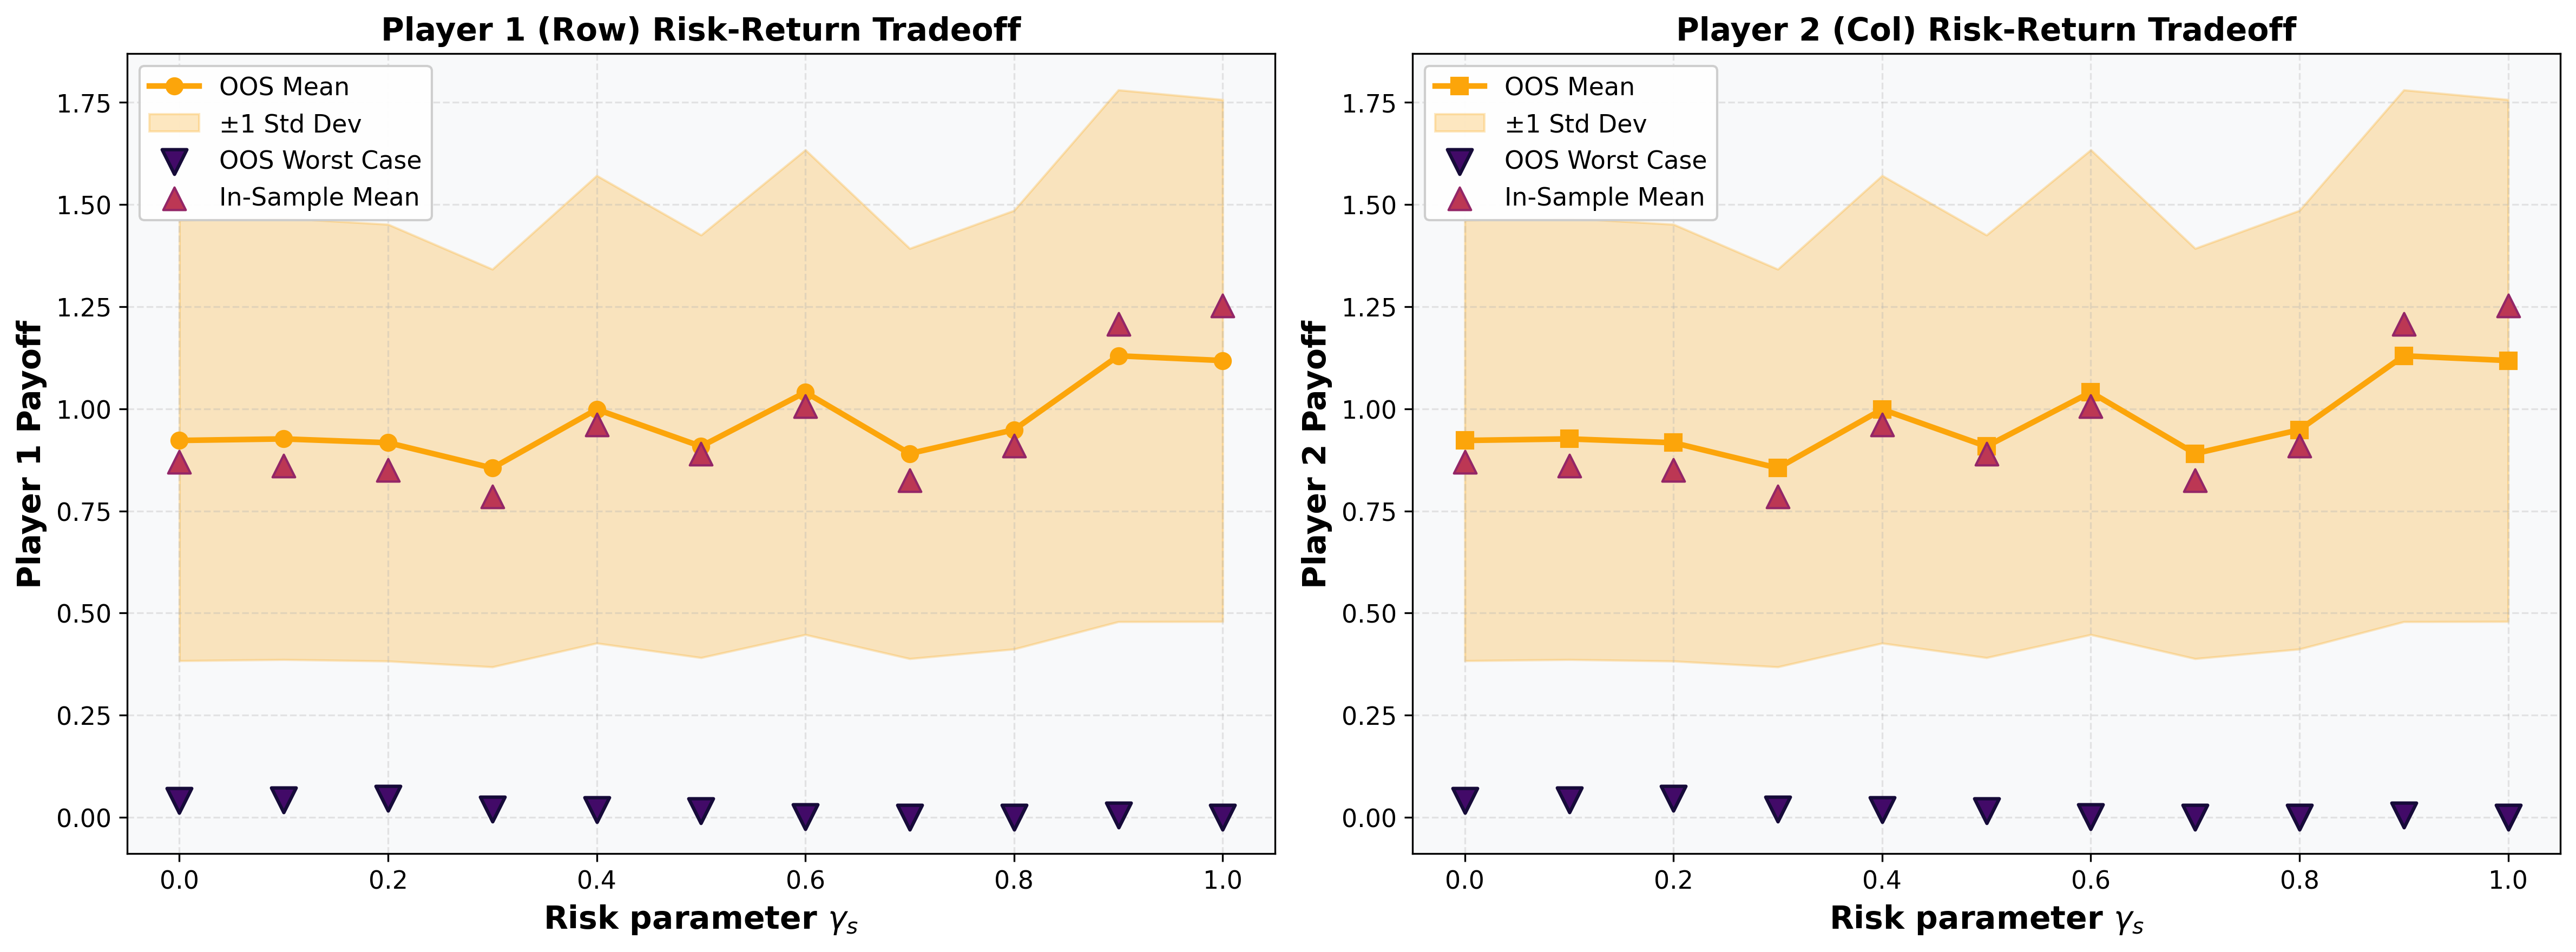


PRISONER'S DILEMMA: KEY RESULTS

OOS Performance Summary:
  γ=0.0 (Risk-neutral):      Mean₁=0.922, Mean₂=0.922
  γ=1.0 (Risk-averse):       Mean₁=1.118, Mean₂=1.118

Worst-case vulnerability (Minimum OOS Payoff):
  γ=0.0:  Min₁=0.042, Min₂=0.042
  γ=1.0:  Min₁=0.000, Min₂=0.000

Standard Deviation (OOS Volatility):
  γ=0.0:  Std₁=0.539, Std₂=0.539
  γ=1.0:  Std₁=0.639, Std₂=0.639


In [522]:
res_mean = res.groupby("gamma").mean().reset_index()
# Visualization: Prisoner's Dilemma Risk-Return Analysis
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
cmap = plt.cm.inferno

# Player 1 (row player)
ax1 = axes[0]
ax1.plot(
    res_mean["gamma"],
    res_mean["oos_mean1"],
    "o-",
    color=cmap(0.8),
    label="OOS Mean",
    linewidth=2.5,
    markersize=7,
)
ax1.fill_between(
    res_mean["gamma"],
    res_mean["oos_mean1"] - res_mean["oos_std1"],
    res_mean["oos_mean1"] + res_mean["oos_std1"],
    alpha=0.25,
    color=cmap(0.8),
    label="±1 Std Dev",
)
ax1.scatter(
    res_mean["gamma"],
    res_mean["oos_min1"],
    color=cmap(0.2),
    s=120,
    marker="v",
    label="OOS Worst Case",
    zorder=6,
    edgecolor=cmap(0.1),
    linewidth=1.5,
)
ax1.scatter(
    res_mean["gamma"],
    res_mean["in_sample_payoff1"],
    color=cmap(0.5),
    s=100,
    marker="^",
    label="In-Sample Mean",
    zorder=6,
    edgecolor=cmap(0.4),
    linewidth=1,
)
ax1.set_xlabel(r"Risk parameter $\gamma_s$", fontsize=14, fontweight="bold")
ax1.set_ylabel("Player 1 Payoff", fontsize=14, fontweight="bold")
ax1.set_title(
    "Player 1 (Row) Risk-Return Tradeoff",
    fontsize=14,
    fontweight="bold",
)
ax1.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle="--")
ax1.set_facecolor("#f8f9fa")

# Player 2 (column player)
ax2 = axes[1]
ax2.plot(
    res_mean["gamma"],
    res_mean["oos_mean2"],
    "s-",
    color=cmap(0.8),
    label="OOS Mean",
    linewidth=2.5,
    markersize=7,
)
ax2.fill_between(
    res_mean["gamma"],
    res_mean["oos_mean2"] - res_mean["oos_std2"],
    res_mean["oos_mean2"] + res_mean["oos_std2"],
    alpha=0.25,
    color=cmap(0.8),
    label="±1 Std Dev",
)
ax2.scatter(
    res_mean["gamma"],
    res_mean["oos_min2"],
    color=cmap(0.2),
    s=120,
    marker="v",
    label="OOS Worst Case",
    zorder=6,
    edgecolor=cmap(0.1),
    linewidth=1.5,
)
ax2.scatter(
    res_mean["gamma"],
    res_mean["in_sample_payoff2"],
    color=cmap(0.5),
    s=100,
    marker="^",
    label="In-Sample Mean",
    zorder=6,
    edgecolor=cmap(0.4),
    linewidth=1,
)
ax2.set_xlabel(r"Risk parameter $\gamma_s$", fontsize=14, fontweight="bold")
ax2.set_ylabel("Player 2 Payoff", fontsize=14, fontweight="bold")
ax2.set_title(
    "Player 2 (Col) Risk-Return Tradeoff",
    fontsize=14,
    fontweight="bold",
)
ax2.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "=" * 70)
print("PRISONER'S DILEMMA: KEY RESULTS")
print("=" * 70)
print("\nOOS Performance Summary:")
print(
    f"  γ=0.0 (Risk-neutral):      Mean₁={res_mean.loc[res_mean['gamma']==0.0, 'oos_mean1'].values[0]:.3f}, Mean₂={res_mean.loc[res_mean['gamma']==0.0, 'oos_mean2'].values[0]:.3f}"
)
print(
    f"  γ=1.0 (Risk-averse):       Mean₁={res_mean.loc[res_mean['gamma']==1.0, 'oos_mean1'].values[0]:.3f}, Mean₂={res_mean.loc[res_mean['gamma']==1.0, 'oos_mean2'].values[0]:.3f}"
)
print(f"\nWorst-case vulnerability (Minimum OOS Payoff):")
print(
    f"  γ=0.0:  Min₁={res_mean.loc[res_mean['gamma']==0.0, 'oos_min1'].values[0]:.3f}, Min₂={res_mean.loc[res_mean['gamma']==0.0, 'oos_min2'].values[0]:.3f}"
)
print(
    f"  γ=1.0:  Min₁={res_mean.loc[res_mean['gamma']==1.0, 'oos_min1'].values[0]:.3f}, Min₂={res_mean.loc[res_mean['gamma']==1.0, 'oos_min2'].values[0]:.3f}"
)
print(f"\nStandard Deviation (OOS Volatility):")
print(
    f"  γ=0.0:  Std₁={res_mean.loc[res_mean['gamma']==0.0, 'oos_std1'].values[0]:.3f}, Std₂={res_mean.loc[res_mean['gamma']==0.0, 'oos_std2'].values[0]:.3f}"
)
print(
    f"  γ=1.0:  Std₁={res_mean.loc[res_mean['gamma']==1.0, 'oos_std1'].values[0]:.3f}, Std₂={res_mean.loc[res_mean['gamma']==1.0, 'oos_std2'].values[0]:.3f}"
)
print("=" * 70)

## Non zero-sum game

In [523]:
import numpy as np

small_sample_size = 5
n_small_sample = 100
n_large_sample = 10000

rng = np.random.default_rng(444)
scenarios = rng.binomial(1, 0.5, (n_small_sample, small_sample_size))
large_n = rng.binomial(1, 0.5, n_large_sample)

p_hat_counts = np.array(
    [
        (scenarios == 0).sum(axis=1),
        (scenarios == 1).sum(axis=1),
    ]
).transpose()
p_hat = p_hat_counts / small_sample_size


def payoff_matrices(state):

    if state == 0:
        return np.array([[2, 0], [2, -1]])
    else:
        return np.array([[0, 0], [2, -1]])


A_payoffs = [payoff_matrices(i) for i in range(2)]
B_payoff = np.array([[3, 2], [0, 1]])
B_payoffs = [B_payoff for _ in range(2)]

A_large_n = [payoff_matrices(s) for s in large_n]
B_large_n = [B_payoff for _ in range(n_large_sample)]
A_payoffs, B_payoffs

([array([[ 2,  0],
         [ 2, -1]]),
  array([[ 0,  0],
         [ 2, -1]])],
 [array([[3, 2],
         [0, 1]]),
  array([[3, 2],
         [0, 1]])])

In [525]:
alpha = 1e-7
gamma = 0.5

res = path_MCP_game_result_cVar(
    A_payoffs, B_payoffs, gamma=gamma, alpha=alpha, p=[0.5, 0.5], verbose=True
)
print("\nAnalytical calculation for alpha < 0.5\n")
# alpha < 0.5
y = 1 / (2 + gamma)
print(f"{y=}")
z = 3 / (2 * (2 + gamma)) - 0.5
print(f"{z=}")
rew = (1 - gamma) / (2 + gamma)
print(f"Expected Reward = {rew}")

# alpha > 0.5
print("\nAnalytical calculation for alpha > 0.5\n")
y = alpha / (2 * alpha + gamma * (1 - alpha))
print(f"{y=}")
z = 5 / 2 * y - 0.5
print(f"{z=}")
rew = y * (2 + (alpha - 1) / (2 * alpha) * gamma) - 0.5
print(f"Expected Reward = {rew}")
# rew = (4 * alpha + (alpha - 1) * gamma) / (4 * alpha + 2 * gamma * (1 - alpha)) - 0.5
# print(f"Expected Reward = {rew}")

res

==================================================PATH Result==================================================
x* = [0.5 0.5]  y* = [0.4 0.6]
alpha1 = 0.2  alpha2 = 1.5
p=[0.5, 0.5]

Analytical calculation for alpha < 0.5

y=0.4
z=0.09999999999999998
Expected Reward = 0.2

Analytical calculation for alpha > 0.5

y=1.99999940000018e-07
z=-0.49999950000015
Expected Reward = -0.9999994000001802


{'x': array([0.5, 0.5]),
 'y': array([0.4, 0.6]),
 'alpha': 1e-07,
 'alpha1': 0.2,
 'alpha2': 1.5,
 'lam1': array([0. , 0.5]),
 'nu1': array([0., 0.]),
 'z1': 0.10000000000000003,
 'lam2': array([0. , 0.5]),
 'nu2': array([0., 0.]),
 'z2': 1.5}

In [526]:
# Summary statistics
print("\n" + "=" * 70)
print("ANALYTICAL CVaR GAME: PAYOFF SURFACE ANALYSIS")
print("=" * 70)
print(f"\nGamma range: [{gamma_lin_fine.min():.3f}, {gamma_lin_fine.max():.3f}]")
print(f"Alpha range: [{alpha_lin_fine.min():.6f}, {alpha_lin_fine.max():.3f}]")
print(f"\nStrategy y*: Min={Y.min():.4f}, Max={Y.max():.4f}")
print(f"VaR threshold z*: Min={Z.min():.4f}, Max={Z.max():.4f}")
print(f"Expected Reward: Min={Reward.min():.4f}, Max={Reward.max():.4f}")
print("\nPhase transition: α = 0.5")
print("  α < 0.5: y* and reward depend only on γ")
print("  α > 0.5: y* and reward depend on both γ and α")
print("=" * 70)


ANALYTICAL CVaR GAME: PAYOFF SURFACE ANALYSIS

Gamma range: [0.000, 1.000]
Alpha range: [0.000000, 1.000]

Strategy y*: Min=0.3333, Max=0.5000
VaR threshold z*: Min=0.0000, Max=0.7500
Expected Reward: Min=0.0000, Max=0.5000

Phase transition: α = 0.5
  α < 0.5: y* and reward depend only on γ
  α > 0.5: y* and reward depend on both γ and α


/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/4021986330.py:6: RuntimeWarning: invalid value encountered in divide
  Y = np.where(Alpha < 0.5, 1.0 / (2 + Gamma), Alpha / (2 * Alpha + Gamma * (1 - Alpha)))
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/4021986330.py:11: RuntimeWarning: invalid value encountered in divide
  (4 * Alpha + (Alpha - 1) * Gamma) / (4 * Alpha + 2 * Gamma * (1 - Alpha)) - 0.5,
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/4021986330.py:16: RuntimeWarning: invalid value encountered in divide
  Alpha**2 / (4 * (2 * Alpha + Gamma * (1 - Alpha)) ** 2),


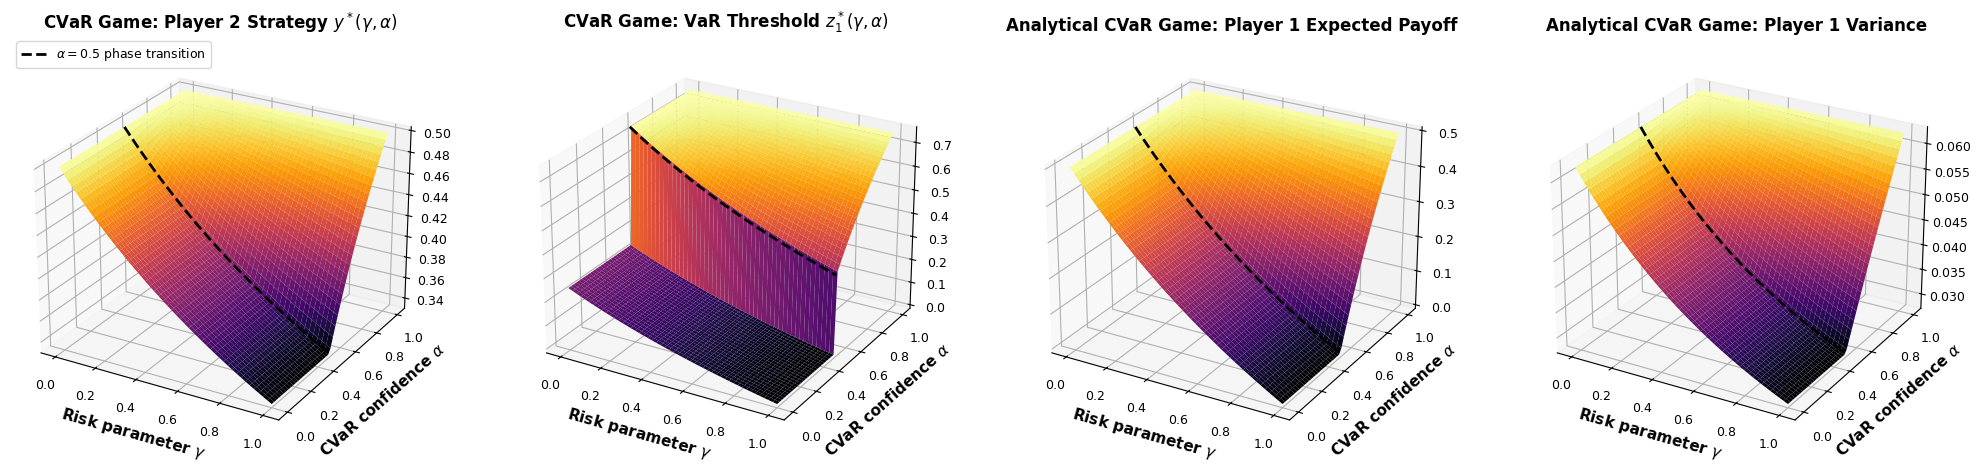

In [527]:
# Combined 3D subplots in a single row
alpha_lin_fine = np.linspace(0, 1.0, 50)
gamma_lin_fine = np.linspace(0, 1.0, 50)
Gamma, Alpha = np.meshgrid(gamma_lin_fine, alpha_lin_fine)

Y = np.where(Alpha < 0.5, 1.0 / (2 + Gamma), Alpha / (2 * Alpha + Gamma * (1 - Alpha)))
Z = np.where(Alpha < 0.5, 3.0 / (2 * (2 + Gamma)) - 0.5, 5.0 / 2 * Y - 0.5)
Reward = np.where(
    Alpha < 0.5,
    (1 - Gamma) / (2 + Gamma),
    (4 * Alpha + (Alpha - 1) * Gamma) / (4 * Alpha + 2 * Gamma * (1 - Alpha)) - 0.5,
)
Var = np.where(
    Alpha < 0.5,
    1 / (4 * (2 + Gamma) ** 2),
    Alpha**2 / (4 * (2 * Alpha + Gamma * (1 - Alpha)) ** 2),
)

plt.rcParams.update(
    {"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9}
)

fig, axs = plt.subplots(1, 4, figsize=(25, 6), subplot_kw={"projection": "3d"})

# shared dashed line data at alpha = 0.5
gamma_line = Gamma[0, :]
alpha_target = 0.5

# Plot 1: Strategy y
surf1 = axs[0].plot_surface(
    Gamma, Alpha, Y, cmap="inferno", linewidth=0, antialiased=True
)
axs[0].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[0].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[0].set_title(
    r"CVaR Game: Player 2 Strategy $y^*(\gamma, \alpha)$",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
y_line = 1 / (2 + gamma_line)
axs[0].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    y_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[0].legend(loc="upper left", fontsize=9)
axs[0].view_init(elev=25, azim=300)

# Plot 2: VaR threshold z
surf2 = axs[1].plot_surface(
    Gamma, Alpha, Z, cmap="inferno", linewidth=0, antialiased=True
)
axs[1].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[1].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[1].set_title(
    r"CVaR Game: VaR Threshold $z_1^*(\gamma, \alpha)$",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
z_line = alpha_target / (2 * alpha_target + gamma_line * (1 - alpha_target))
z_line = 5.0 / 2 * z_line - 0.5
axs[1].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    z_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[1].view_init(elev=25, azim=300)

# Plot 3: Expected reward
surf3 = axs[2].plot_surface(
    Gamma, Alpha, Reward, cmap="inferno", linewidth=0, antialiased=True
)
axs[2].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[2].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[2].set_title(
    r"Analytical CVaR Game: Player 1 Expected Payoff",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
reward_line = (4 * alpha_target + (alpha_target - 1) * gamma_line) / (
    4 * alpha_target + 2 * gamma_line * (1 - alpha_target)
) - 0.5
axs[2].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    reward_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[2].view_init(elev=25, azim=300)

# Plot 4: Variance
surf3 = axs[3].plot_surface(
    Gamma, Alpha, Var, cmap="inferno", linewidth=0, antialiased=True
)
axs[3].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[3].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[3].set_title(
    r"Analytical CVaR Game: Player 1 Variance",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
var_line = 1 / (4 * (2 + gamma_line) ** 2)

axs[3].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    var_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[3].view_init(elev=25, azim=300)


plt.show()

### Fig 4

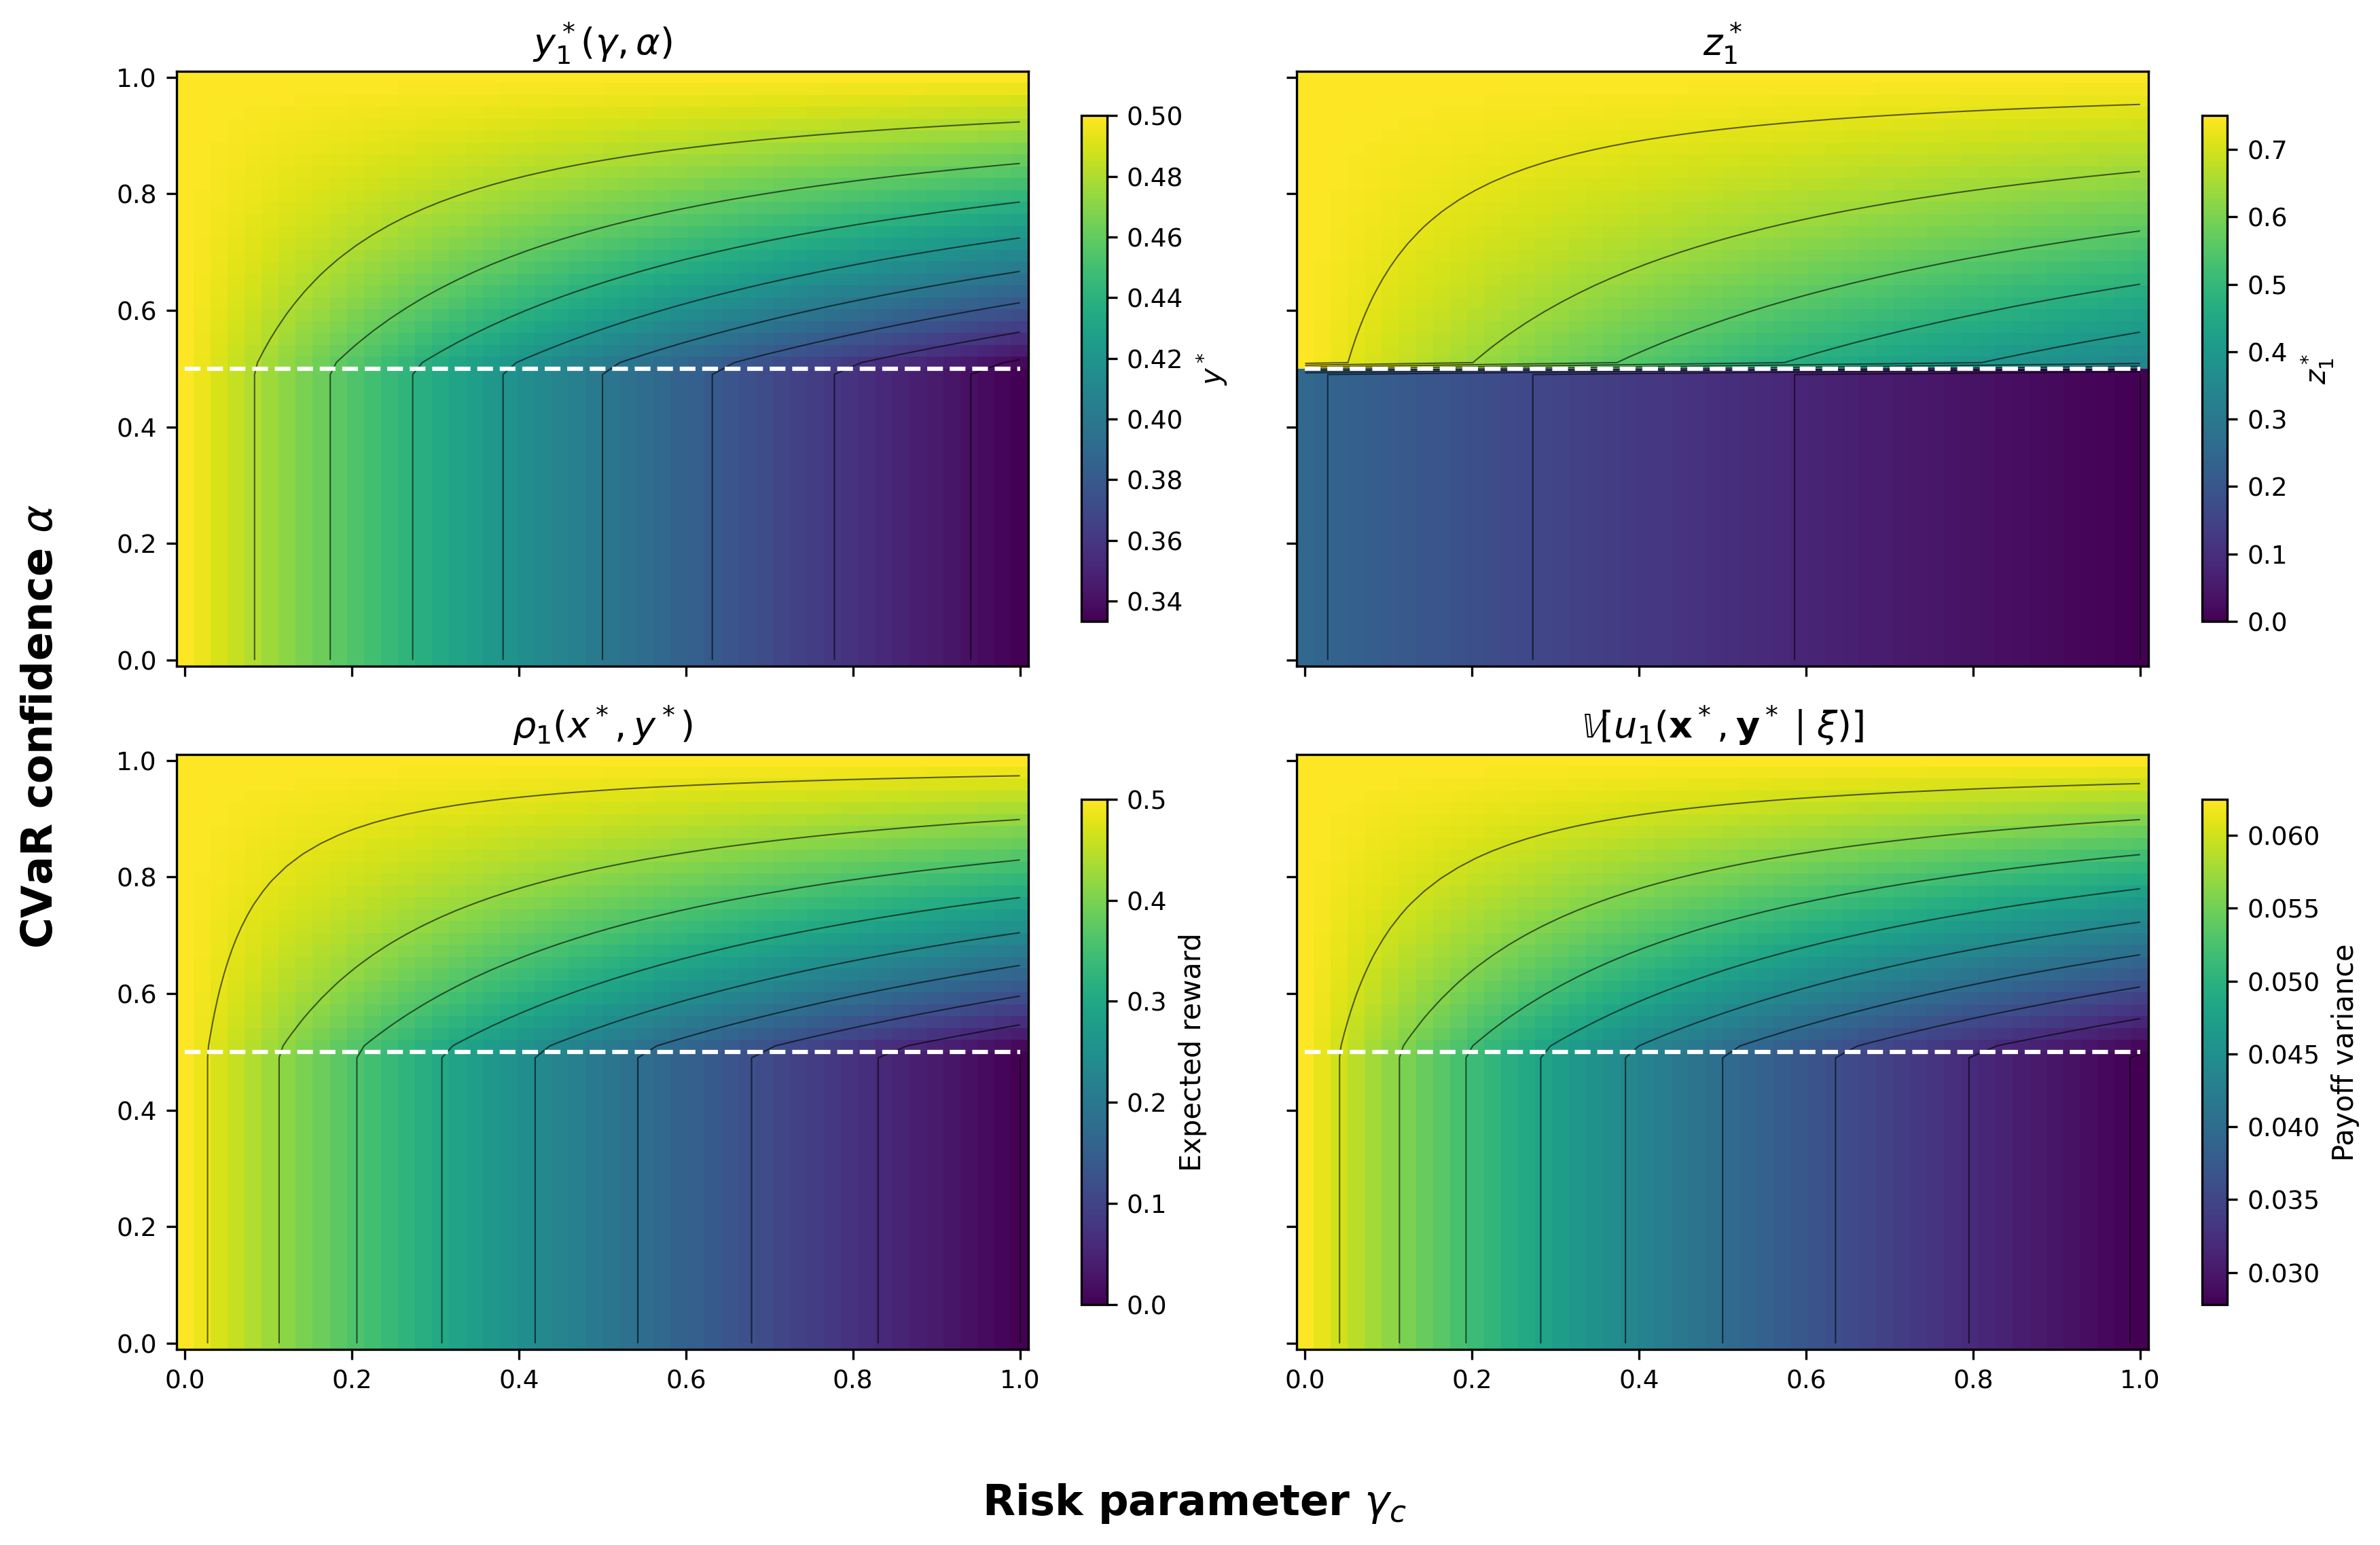

In [528]:
# Combined horizontal subplots with single shared x/y labels
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True, dpi=300)
cmap = "viridis"


# Strategy y* contour
CS = axs[0, 0].pcolormesh(gamma_vals, alpha_vals, Y, cmap=cmap, shading="auto")
axs[0, 0].set_title(r"$y_1^*(\gamma,\alpha)$", fontsize=13, fontweight="bold")
axs[0, 0].contour(
    gamma_vals, alpha_vals, Y, levels=8, colors="k", linewidths=0.5, alpha=0.6
)
axs[0, 0].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar0 = fig.colorbar(CS, ax=axs[0, 0], shrink=0.85)
cbar0.set_label(r"$y^*$", fontsize=10)

# Expected Reward heatmap
pcm0 = axs[1, 0].pcolormesh(gamma_vals, alpha_vals, Reward, cmap=cmap, shading="auto")
axs[1, 0].contour(
    gamma_vals, alpha_vals, Reward, levels=8, colors="k", linewidths=0.5, alpha=0.6
)
axs[1, 0].set_title(r"$\rho_1(x^*, y^*)$", fontsize=13, fontweight="bold")
axs[1, 0].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar1 = fig.colorbar(pcm0, ax=axs[1, 0], shrink=0.85)
cbar1.set_label("Expected reward", fontsize=10)

# VaR z*
pcm2 = axs[0, 1].pcolormesh(gamma_vals, alpha_vals, Z, cmap=cmap, shading="auto")
axs[0, 1].set_title(r"$z_1^*$", fontsize=13, fontweight="bold")
axs[0, 1].contour(
    gamma_vals, alpha_vals, Z, levels=10, colors="k", linewidths=0.5, alpha=0.6
)
axs[0, 1].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar2 = fig.colorbar(pcm2, ax=axs[0, 1], shrink=0.85)
cbar2.set_label(r"$z_1^*$", fontsize=10)

# Var payoff
pcm3 = axs[1, 1].pcolormesh(gamma_vals, alpha_vals, Var, cmap=cmap, shading="auto")
axs[1, 1].set_title(
    r"$\mathbb{V}[u_1(\mathbf{x}^*, \mathbf{y}^* \mid \xi)]$",
    fontsize=13,
    fontweight="bold",
)
axs[1, 1].contour(
    gamma_vals, alpha_vals, Var, levels=10, colors="k", linewidths=0.5, alpha=0.6
)
axs[1, 1].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar2 = fig.colorbar(pcm3, ax=axs[1, 1], shrink=0.85)
cbar2.set_label(r"Payoff variance", fontsize=10)


# Single shared axis labels
fig.supxlabel(r"Risk parameter $\gamma_c$", fontsize=15, fontweight="bold")
fig.supylabel(r"CVaR confidence $\alpha$", fontsize=15, fontweight="bold")

plt.tight_layout(rect=[0.02, 0.03, 1, 0.95])
plt.show()